First 5 rows:
   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              ---------

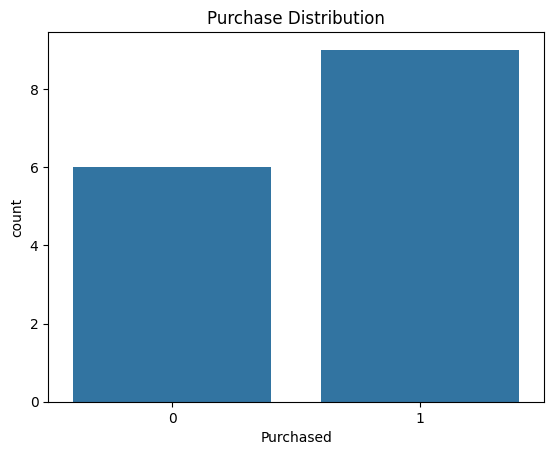


Missing Values
CustomerID            0
Age                   0
Gender                0
Device                0
Traffic_Source        0
Time_on_Website       0
Pages_Visited         0
Ad_Clicks             0
Previous_Purchases    0
Purchased             0
dtype: int64

Numerical Columns: Index(['Age', 'Time_on_Website', 'Pages_Visited', 'Ad_Clicks',
       'Previous_Purchases'],
      dtype='str')
Categorical Columns: Index(['Gender', 'Device', 'Traffic_Source'], dtype='str')


C:\Users\princ\AppData\Local\Temp\ipykernel_19240\2390703238.py:132: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns



Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



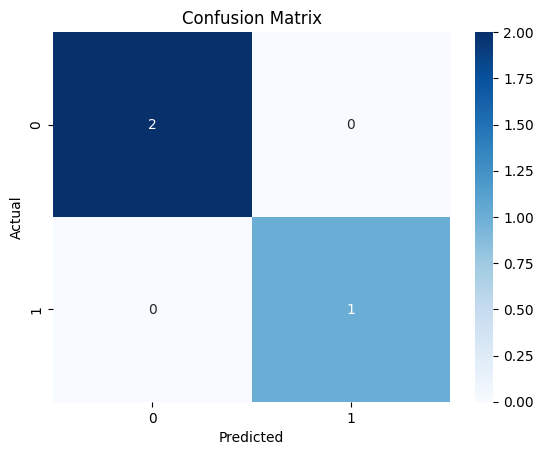

C:\Users\princ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Best Parameters:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Final Accuracy: 1.0

Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



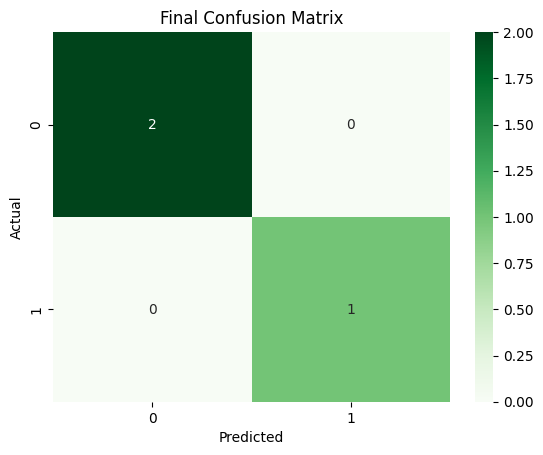

In [5]:
"""
Capstone Project 3 
Smart Marketing Prediction System (ML Pipeline Project)
Scenario
A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

Currently:

Many customers browse but never purchase

Marketing money is wasted on the wrong users

The company wants to predict purchase probability

The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

If the system predicts high probability of purchase, the system will:

show personalized product recommendations

offer targeted discounts

prioritize marketing campaigns

If the system predicts low probability, the company will avoid spending marketing resources.

However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

Business Objective
Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

The model must be implemented using scikit-learn pipelines, including:

Encoding techniques

Feature preprocessing

Model training

Model selection

Hyperparameter tuning
"""
# 1. Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV



# 2. Load Dataset


df = pd.read_excel("DatasetCapstoneProject3.xlsx")

print("First 5 rows:")
print(df.head())



# 3. Basic Dataset Information


print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


# 4. Check Target Variable


print("\nTarget Distribution")
print(df["Purchased"].value_counts())

sns.countplot(x="Purchased", data=df)
plt.title("Purchase Distribution")
plt.show()



# 5. Check Missing Values


print("\nMissing Values")
print(df.isnull().sum())

# Drop if any missing
df = df.dropna()



# 6. Remove CustomerID (not useful for ML)


df = df.drop("CustomerID", axis=1)



# 7. Separate Features and Target


X = df.drop("Purchased", axis=1)
y = df["Purchased"]



# 8. Identify Numerical and Categorical Columns


num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)



# 9. Preprocessing


num_transformer = StandardScaler()

cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)



# 10. Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# 11. Create ML Pipeline


pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])



# 12. Train Model


pipeline.fit(X_train, y_train)



# 13. Predictions


y_pred = pipeline.predict(X_test)



# 14. Model Evaluation


print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



# 15. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# 16. Hyperparameter Tuning


param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 17. Best Parameters


print("\nBest Parameters:")
print(grid_search.best_params_)



# 18. Final Model Evaluation


best_model = grid_search.best_estimator_

final_pred = best_model.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, final_pred))

print("\nFinal Classification Report:")
print(classification_report(y_test, final_pred))



# 19. Final Confusion Matrix


final_cm = confusion_matrix(y_test, final_pred)

sns.heatmap(final_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
"""
Capstone Project 4
Project Scenario
Smart Traffic Sign Recognition System
Scenario
A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

1️⃣ First, the system must understand basic classification logic (learning from features).
2️⃣ Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.
"""
# 1. Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# 2. Load Dataset


df = pd.read_csv("DatasetCapstoneProject4.csv")

print("First 5 rows")
print(df.head())



# 3. Dataset Information


print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())



# 4. Check Target Distribution


print("\nTarget Distribution")
print(df["Label"].value_counts())

sns.countplot(x="Label", data=df)
plt.title("STOP vs NOT STOP Distribution")
plt.show()



# 5. Separate Features and Target


X = df.drop("Label", axis=1)
y = df["Label"]



# 6. Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# 7. Feature Scaling


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# 8. Train Perceptron Model


model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

model.fit(X_train, y_train)


# 9. Make Predictions


y_pred = model.predict(X_test)



# 10. Model Evaluation


accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))



# 11. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# 12. Model Weights (How Perceptron Learns)


print("\nModel Weights:")
print(model.coef_)

print("\nModel Bias:")
print(model.intercept_)

First 5 rows
   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sign_ID              10 non-null     int64  
 1   Red_Color_Intensity  10 non-null     float64
 2   Circular_Shape       10 non-null     int64  
 3   Text_Present         10 non-null     int64  
 4   Edge_Count           10 n

KeyError: 'Label'